### Simple Chatbot using Langgraph

In [2]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings


llm=ChatGroq(model="llama-3.1-8b-instant")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10892.65it/s]


In [3]:
llm.invoke("Hii").content

'How can I assist you today?'

In [4]:
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.graph.message import add_messages
from typing import Annotated,Literal,TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import ToolNode

In [5]:
def call_model(state:MessagesState):
    messages=state["messages"]
    response=llm.invoke(messages)
    return {"messages":[response]}

In [6]:
workflow1=StateGraph(MessagesState)

In [7]:
workflow1.add_node("chatbot",call_model)

workflow1.add_edge(START,"chatbot")
workflow1.add_edge("chatbot",END)


In [8]:
app=workflow1.compile()

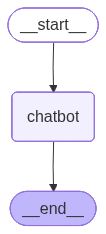

In [9]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [10]:
input={"messages":["Hii my name is Sanskar"]}

In [11]:
app.invoke(input)["messages"][-1].content

'Nice to meet you, Sanskar. How are you today? Is there something I can help you with or would you like to chat?'

### Adding tools in Chatbot using Langgraph

In [12]:
@tool
def search(query:str):
    """This is my custom tool to provide the temperature
    
    Args:
        query: String
    """
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degree and foggy"
    return "It's 90 degree and sunny"

In [13]:
search.invoke("what is the temperature of sf")

"It's 60 degree and foggy"

In [14]:
tools=[search]

In [15]:
tool_node=ToolNode(tools)

In [16]:
llm_with_tools=llm.bind_tools(tools)

In [17]:
def call_model(state:MessagesState):
    messages=state["messages"]
    response=llm_with_tools.invoke(messages)
    return {"messages":[response]}

In [18]:
response=call_model({"messages":["Hii"]})

In [19]:
response["messages"][-1].content

"Unfortunately, I can't have a chat with you in the format you've specified. However, I can assist you with your queries in a normal conversation format if you'd like. What would you like help with today?"

In [20]:
response=call_model({"messages" :[HumanMessage(content="What is the temperature of India, Use search tool")]})

In [21]:
response["messages"][-1].tool_calls


[{'name': 'search',
  'args': {'query': 'temperature of India'},
  'id': 'aeyhex3ks',
  'type': 'tool_call'}]

In [22]:
## Conditional router function

def router_function(state:MessagesState)->Literal["tools","end"]:
    last_message=state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return "end"

In [23]:
workflow2=StateGraph(MessagesState)


In [24]:
workflow2.add_node("agent",call_model)
workflow2.add_node("tools",tool_node)


In [25]:
workflow2.add_edge(START,"agent")
workflow2.add_conditional_edges("agent",router_function,{"tools":"tools","end":END})
workflow2.add_edge("tools", "agent") 

In [26]:
app=workflow2.compile()

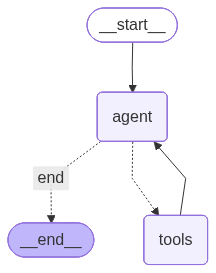

In [27]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [28]:
app.invoke({"messages":"Hii"})

{'messages': [HumanMessage(content='Hii', additional_kwargs={}, response_metadata={}, id='cd643082-5b1c-458d-8973-f0293a512dcc'),
  AIMessage(content="I'm happy to help you with any questions or tasks you have. What would you like to do today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 236, 'total_tokens': 259, 'completion_time': 0.03754079, 'completion_tokens_details': None, 'prompt_time': 0.013973067, 'prompt_tokens_details': None, 'queue_time': 0.050789342, 'total_time': 0.051513857}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de784-5f72-7d11-85e4-19365f91aaee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 236, 'output_tokens': 23, 'total_tokens': 259})]}

In [32]:
app.invoke({"messages":["What is the weather of india, Us e search tool"]})

{'messages': [HumanMessage(content='What is the weather of india, Us e search tool', additional_kwargs={}, response_metadata={}, id='a381bafa-8e60-4969-8bc2-f918ec401d40'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vt1t9s3ba', 'function': {'arguments': '{"query":"India weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 245, 'total_tokens': 259, 'completion_time': 0.021342627, 'completion_tokens_details': None, 'prompt_time': 0.015057164, 'prompt_tokens_details': None, 'queue_time': 0.052131575, 'total_time': 0.036399791}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de787-aa1b-71d3-acc1-7c40a10c7994-0', tool_calls=[{'name': 'search', 'args': {'query': 'India weather'}, 'id': 'vt1t9s3ba', 'type': 'tool_call'}], invalid_tool_calls=[], u